In [1]:
%run -i /lfs/l7/hess/users/sghosh/projects/Satellite-trails/functions_import_essential_novae.py

path_eval is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc/high_pixel"
path_eval_cut is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel"


In [1]:
from functions_import_essential_novae import *

path_eval is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc/high_pixel"
path_eval_cut is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel"


In [62]:
import pandas as pd
from flatfielding import FlatFieldModel

fmodel = FlatFieldModel()
date   = pd.to_datetime("2020-07-18")
tel_id = 5

coeffs = fmodel.get_FlatField(date, tel_id)
coeffs_array = np.array(coeffs)
print(coeffs)

coeffs_array[0][0]

#save the coefficients to a txt file as a table
# The first column is the pixel number, the second is the high-gain coefficient, and
# the third is the low-gain coefficient, fourth is charge_mean_hg, and fifth is charge_mean_lg
# Use spacing as proper delimiter
np.savetxt(f"flatfield_coeffs_tel{tel_id}.txt", coeffs_array, fmt='%.6f', delimiter=' ', header='Pixel HighGain LowGain ChargeMeanHG ChargeMeanLG')


       Coefficient_hg  Coefficient_lg  charge_mean_hg  charge_mean_lg
Pixel                                                                
0            0.977048        0.977048         129.147            -1.0
1            0.991012        0.991012         131.184            -1.0
2            0.891101        0.891101         117.937            -1.0
3            0.912502        0.912502         120.954            -1.0
4            0.845686        0.845686         111.651            -1.0
...               ...             ...             ...             ...
1759         1.074620        1.074620         140.832            -1.0
1760         1.043050        1.043050         136.089            -1.0
1761         0.990256        0.990256         129.743            -1.0
1762         0.983795        0.983795         128.534            -1.0
1763         1.041050        1.041050         136.216            -1.0

[1764 rows x 4 columns]


In [78]:
coeffs_array[3][0]

0.912502

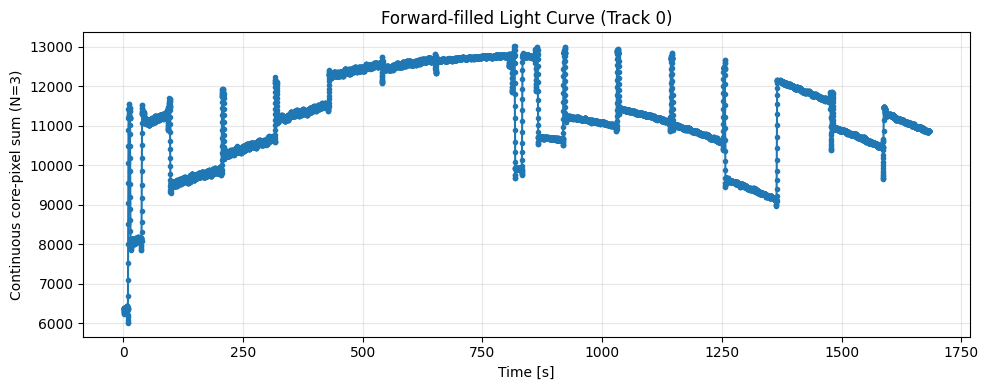

(array([5.50000e-01, 6.50000e-01, 7.50000e-01, ..., 1.68275e+03,
        1.68285e+03, 1.68295e+03]),
 array([ 6237.98507623,  6255.07954037,  6271.1119789 , ...,
        10866.54701233, 10867.28211519, 10868.23060982]))

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.signal import savgol_filter

def plot_continuous_core_flux(tracks, track_number=0, dt=0.1,
                              core_size=3, sg_window=21, sg_order=2):
    # Unpack
    pix_ids, times, br = tracks[track_number]
    pix_ids = np.array(pix_ids, int)
    times   = np.array(times)
    br      = np.array(br)

    # Pick the N most‐frequent (core) pixels
    freq = Counter(pix_ids)
    core = [p for p,_ in freq.most_common(core_size)]

    # Make uniform bins
    t0, t1 = times.min(), times.max()
    bins   = np.arange(t0, t1 + dt, dt)
    nbin   = len(bins) - 1
    tc     = bins[:-1] + dt/2

    # Assign hits to bins
    idxs = np.searchsorted(bins, times, side='right') - 1
    hits = [[] for _ in range(nbin)]
    for p,b,bi in zip(pix_ids, br, idxs):
        if 0 <= bi < nbin and p in core:
            hits[bi].append((p, b))

    # Forward‐fill each pixel’s last value, then sum
    last = {p: 0.0 for p in core}
    flux = np.zeros(nbin)
    for bi in range(nbin):
        for p, b in hits[bi]:
            last[p] = b
        flux[bi] = sum(last.values())

    # Optional Savitzky–Golay to polish
    wl = min(sg_window, nbin - (1 - nbin%2))
    if wl % 2 == 0: wl -= 1
    flux = savgol_filter(flux, window_length=wl, polyorder=sg_order, mode='interp')

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(tc, flux, '-o', ms=3)
    plt.xlabel('Time [s]')
    plt.ylabel(f'Continuous core‐pixel sum (N={core_size})')
    plt.title(f'Forward-filled Light Curve (Track {track_number})')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return tc, flux

# Usage:
plot_continuous_core_flux(tracks, track_number=0, dt=0.1)


In [10]:
def save_tracks_hits(run_number, output_file):
    """
    Processes a given run with track_sorter and writes every hit in each track
    as a row in a text file with columns: track_id, pixel_id, time[s], brightness.

    Parameters:
    - run_number: int or str, the run identifier
    - output_file: str, path to the output .txt file
    """
    # Build neighbor list
    typed_nn_pix = get_typed_nn_pix(5)

    # Read run data
    pix_arr, time_arr, bright_arr = read_single_run_utc_cut(run_number)

    # Detect tracks
    tracks, _ = track_sorter(pix_arr, time_arr, bright_arr, typed_nn_pix)

    # Write out hits
    with open(output_file, 'w') as f:
        # Header
        f.write("# track_id\tpixel_id\ttime[s]\tbrightness\n")
        # Loop tracks and hits
        for tid, tr in enumerate(tracks):
            pix_list = tr[0]
            time_list = tr[1]
            bright_list = tr[2]
            for p, t, b in zip(pix_list, time_list, bright_list):
                f.write(f"{tid}\t{int(p)}\t{t:.6f}\t{b:.6f}\n")

    print(f"Saved {sum(len(tr[0]) for tr in tracks)} hits from {len(tracks)} tracks to '{output_file}'")

save_tracks_hits(161164, "tracks_161164.txt")

Reading high_pix_161164_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161164/high_pix_161164_CT_5_cut.h5
read pix:
read time:
read brightness:
Saved 84720 hits from 3 tracks to 'tracks_161164.txt'


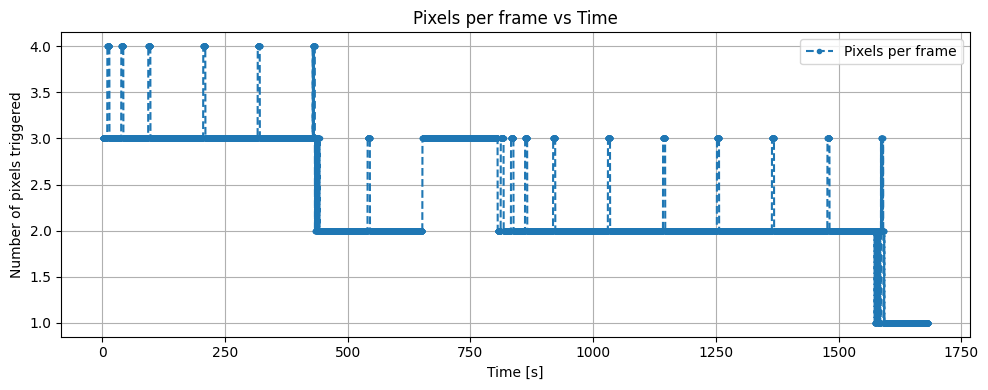

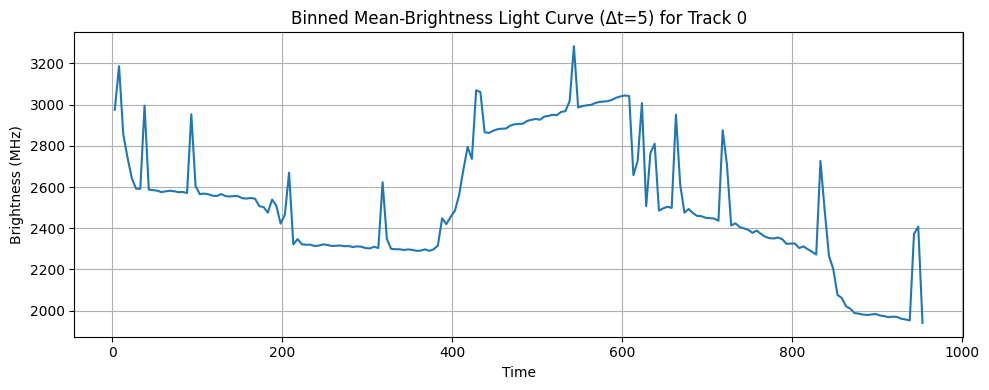

Track 0 overall mean brightness: 2527.866 MHz


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# load the columns, skipping “#” lines
data = np.loadtxt('/lfs/l7/hess/users/sghosh/tracks_161097.txt', 
                  delimiter='\t',
                  comments='#',
                  usecols=(0,1,2,3))

# unpack
track_ids, pixel_ids, times, brightness = data.T

# mask just track 0
mask0 = track_ids == 0
times0 = times[mask0]

# count occurrences of each time
cnt = Counter(times0)

# sort by time
t_sorted = np.array(sorted(cnt.keys()))
n_pix    = np.array([cnt[t] for t in t_sorted])

# plot
plt.figure(figsize=(10,4))
plt.plot(t_sorted, n_pix, marker='.', linestyle='--')
# plt.plot(unique_t, flux_mean, color='red' )
plt.xlabel('Time [s]')
plt.ylabel('Number of pixels triggered')
plt.title('Pixels per frame vs Time')
plt.tight_layout()
plt.grid()
plt.legend(['Pixels per frame', 'Mean Pixel Brightness'])
plt.show()

plot_binned_mean_flux_light_curve(tracks, track_number=0, time_bin_size=5)

In [76]:
import numpy as np
import pandas as pd
from collections import defaultdict
import plotly.express as px

# load your data as before
data = np.loadtxt('/lfs/l7/hess/users/sghosh/tracks_161097.txt', 
                  delimiter='\t', comments='#', usecols=(0,1,2,3))
track_ids, pixel_ids, times, brightness = data.T

# select track 0
mask0 = track_ids == 0
times0 = times[mask0]
pix0   = pixel_ids[mask0]

# group pixel IDs by time
pix_by_time = defaultdict(list)
for t, pid in zip(times0, pix0):
    pix_by_time[t].append(int(pid))

# get sorted times and counts
t_sorted = np.array(sorted(pix_by_time.keys()))
n_pix    = np.array([len(pix_by_time[t]) for t in t_sorted])

# make DataFrame, with a hover-friendly string of IDs
df = pd.DataFrame({
    'time_s': t_sorted,
    'n_pixels': n_pix,
    # join into comma-sep string; you can leave them as lists if you prefer
    'pix_ids': [','.join(map(str, pix_by_time[t])) for t in t_sorted]
})

# now plot with pix_ids in the hover
fig = px.line(
    df,
    x='time_s',
    y='n_pixels',
    markers=True,
    title='Pixels per frame vs Time',
    hover_data={'pix_ids':True,  # include the pix_ids column
                'time_s':False,  # hide redundant time
                'n_pixels':False # hide redundant y
               }
)

# tweak axis labels
fig.update_layout(
    xaxis_title='Time [s]',
    yaxis_title='Number of pixels triggered',
    template='plotly_white'
)

fig.show()


In [82]:
print("Pix_ID:600 ; FF-coeff:", coeffs_array[600][0])
print("Pix_ID:604 ; FF-coeff:", coeffs_array[604][0])
print("Pix_ID:606 ; FF-coeff:", coeffs_array[606][0])
print("Pix_ID:766 ; FF-coeff:", coeffs_array[766][0])

Pix_ID:600 ; FF-coeff: 0.985183
Pix_ID:604 ; FF-coeff: 0.975586
Pix_ID:606 ; FF-coeff: 0.995221
Pix_ID:766 ; FF-coeff: 0.937047


In [18]:
import pandas as pd
import plotly.express as px

# === Load geometry ===
geom_file_path = "/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt"
df_geom = pd.read_csv(geom_file_path, sep=";", header=None, names=["pix_id", "x", "y"])

fig = px.scatter(
    df_geom,
    x="x",
    y="y",
    hover_name="pix_id",
    title="FlashCam Geometry — hover for pix_id",
    width=600, height=600
)
fig.update_layout(yaxis=dict(scaleanchor="x", scaleratio=1))
fig.show()


[[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 20, 22, 23, 28, 29, 41, 43, 45, 46, 47, 1209, ...], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 20, 22, 28, 29, 30, 45, 595, 597, 1184, 1186, ...], [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 20, 22, 24, 28, 29, 30, 31, 41, 43, 45, 46, 47, 593, ...], [0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 20, 25, 28, 29, 30, 31, 33, 45, 593, 594, 595, 597, 1186, ...], [0, 1, 4, 5, 6, 7, 9, 13, 15, 18, 19, 20, 21, 22, 23, 45, 1184, 1186, 1201, 1207, 1209, 1210, 1211, ...], [0, 1, 2, 4, 5, 6, 7, 9, 11, 19, 21, 22, 23, 1179, 1184, 1185, 1186, 1187, 1205, 1206, 1207, 1209, 1211, ...], [0, 1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15, 20, 21, 22, 23, 28, 45, 597, 1184, 1186, 1207, 1209, ...], [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 22, 23, 29, 597, 599, 1179, 1184, 1185, 1186, 1187, 1205, 1209, ...], [1, 2, 3, 8, 9, 10, 11, 25, 27, 28, 29, 30, 31, 33, 35, 45, 592, 593, 594, 595, 597, 609, 610, ...], [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 591, 595, 597, 598, 599, 1177, 1178, 1179, 1183, 1184, 1185, 1186,

7 7 7


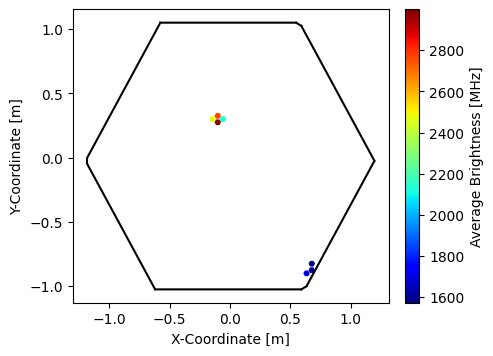

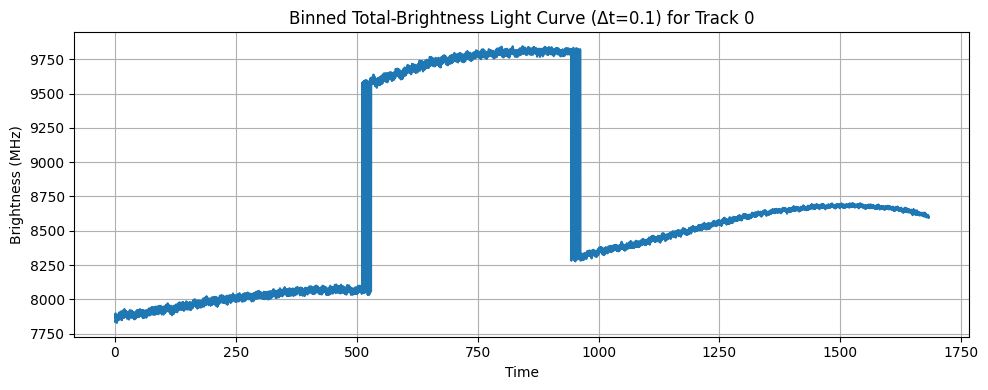

Track 0 overall mean brightness: 2687.061 MHz


In [11]:
typed_nn_pix = get_typed_nn_pix(5)
print(typed_nn_pix)

new_high_pixel = read_single_run_utc_cut(161197)
pix = new_high_pixel[0]
tmp = new_high_pixel[1]
brightness = new_high_pixel[2]

tracks, possible_meteorites = track_sorter(pix, tmp, brightness, typed_nn_pix)

print(tracks)

for i, track in enumerate(tracks):
    pix = track[0]
    times = track[1]
    brightness = track[2]
    print(f"Track {i} — Unique Pixels: {len(set(pix))}")
    print(f"  First  → Pixel ID: {pix[0]}, Time: {times[0]}, Brightness: {brightness[0]}")
    print(f"  Last   → Pixel ID: {pix[-1]}, Time: {times[-1]}, Brightness: {brightness[-1]}")

plot_brightness_in_trackly(tracks)
plot_brightness_in_track(tracks)
plot_binned_total_flux_light_curve(tracks, track_number=0, time_bin_size=0.1)
plt.show()

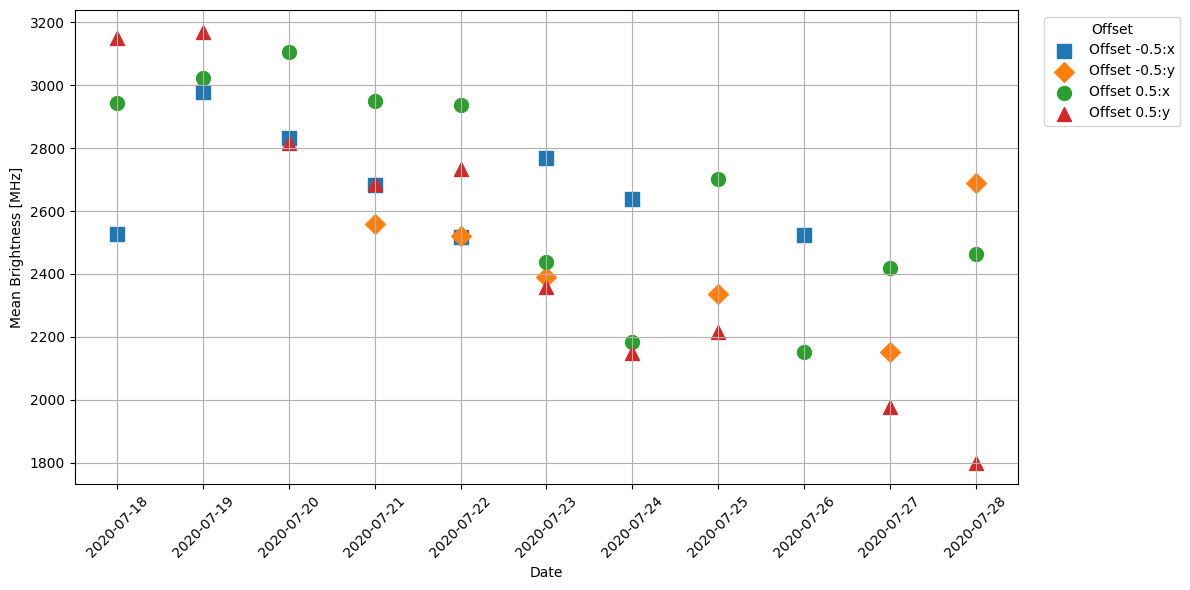

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── DATA WITH OFFSETS ───────────────────────────────────────────────────────
data = [
    {"Date":"2020-07-18","Run":161096,"Mean Brightness [MHz]":2943.363, "Offset":"0.5:x"},
    {"Date":"2020-07-18","Run":161097,"Mean Brightness [MHz]":3150.556, "Offset":"0.5:y"},
    {"Date":"2020-07-18","Run":161098,"Mean Brightness [MHz]":2527.866, "Offset":"-0.5:x"},
    {"Date":"2020-07-19","Run":161131,"Mean Brightness [MHz]":3023.083, "Offset":"0.5:x"},
    {"Date":"2020-07-19","Run":161132,"Mean Brightness [MHz]":3170.233, "Offset":"0.5:y"},
    {"Date":"2020-07-19","Run":161133,"Mean Brightness [MHz]":2979.410, "Offset":"-0.5:x"},
    {"Date":"2020-07-20","Run":161163,"Mean Brightness [MHz]":3105.316, "Offset":"0.5:x"},
    {"Date":"2020-07-20","Run":161164,"Mean Brightness [MHz]":2817.080, "Offset":"0.5:y"},
    {"Date":"2020-07-20","Run":161165,"Mean Brightness [MHz]":2833.112, "Offset":"-0.5:x"},
    {"Date":"2020-07-21","Run":161195,"Mean Brightness [MHz]":2560.218, "Offset":"-0.5:y"},
    {"Date":"2020-07-21","Run":161196,"Mean Brightness [MHz]":2950.974, "Offset":"0.5:x"},
    {"Date":"2020-07-21","Run":161197,"Mean Brightness [MHz]":2687.061, "Offset":"0.5:y"},
    {"Date":"2020-07-21","Run":161198,"Mean Brightness [MHz]":2683.811, "Offset":"-0.5:x"},
    {"Date":"2020-07-22","Run":161224,"Mean Brightness [MHz]":2520.806, "Offset":"-0.5:y"},
    {"Date":"2020-07-22","Run":161225,"Mean Brightness [MHz]":2938.140, "Offset":"0.5:x"},
    {"Date":"2020-07-22","Run":161226,"Mean Brightness [MHz]":2734.072, "Offset":"0.5:y"},
    {"Date":"2020-07-22","Run":161227,"Mean Brightness [MHz]":2517.722, "Offset":"-0.5:x"},
    {"Date":"2020-07-23","Run":161268,"Mean Brightness [MHz]":2437.234, "Offset":"0.5:x"},
    {"Date":"2020-07-23","Run":161269,"Mean Brightness [MHz]":2359.402, "Offset":"0.5:y"},
    {"Date":"2020-07-23","Run":161270,"Mean Brightness [MHz]":2769.977, "Offset":"-0.5:x"},
    {"Date":"2020-07-23","Run":161271,"Mean Brightness [MHz]":2390.268, "Offset":"-0.5:y"},
    {"Date":"2020-07-24","Run":161306,"Mean Brightness [MHz]":2183.131, "Offset":"0.5:x"},
    {"Date":"2020-07-24","Run":161307,"Mean Brightness [MHz]":2147.676, "Offset":"0.5:y"},
    {"Date":"2020-07-24","Run":161308,"Mean Brightness [MHz]":2638.964, "Offset":"-0.5:x"},
    {"Date":"2020-07-25","Run":161334,"Mean Brightness [MHz]":2335.503, "Offset":"-0.5:y"},
    {"Date":"2020-07-25","Run":161335,"Mean Brightness [MHz]":2703.214, "Offset":"0.5:x"},
    {"Date":"2020-07-25","Run":161336,"Mean Brightness [MHz]":2214.348, "Offset":"0.5:y"},
    {"Date":"2020-07-26","Run":161366,"Mean Brightness [MHz]":2150.789, "Offset":"0.5:x"},
    {"Date":"2020-07-26","Run":161367,"Mean Brightness [MHz]":np.nan,    "Offset":"0.5:y"},
    {"Date":"2020-07-26","Run":161368,"Mean Brightness [MHz]":2523.884, "Offset":"-0.5:x"},
    {"Date":"2020-07-27","Run":161426,"Mean Brightness [MHz]":2152.031, "Offset":"-0.5:y"},
    {"Date":"2020-07-27","Run":161427,"Mean Brightness [MHz]":2418.212, "Offset":"0.5:x"},
    {"Date":"2020-07-27","Run":161428,"Mean Brightness [MHz]":1978.479, "Offset":"0.5:y"},
    {"Date":"2020-07-28","Run":161476,"Mean Brightness [MHz]":1800.373, "Offset":"0.5:y"},
    {"Date":"2020-07-28","Run":161477,"Mean Brightness [MHz]":2464.288, "Offset":"0.5:x"},
    {"Date":"2020-07-28","Run":161478,"Mean Brightness [MHz]":2689.861, "Offset":"-0.5:y"},
]

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Mean Brightness [MHz]'])

# Map offsets to marker shapes
offset_to_marker = {
    "0.5:x":  "o",  # circle
    "-0.5:x": "s",  # square
    "0.5:y":  "^",  # triangle up
    "-0.5:y": "D",  # diamond
}

# ─── SELECT WHICH OFFSETS TO PLOT ────────────────────────────────────────────
# e.g. show only X+ and Y– offsets:
# offsets_to_plot = ["0.5:x", "-0.5:y"]
# or for just one:
# offsets_to_plot = ["-0.5:x"]
# or to show all, uncomment the next line:
offsets_to_plot = list(offset_to_marker.keys())

# ─── PLOTTING ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for offset, grp in df.groupby("Offset"):
    if offset not in offsets_to_plot:
        continue
    marker = offset_to_marker[offset]
    ax.scatter(
        grp["Date"],
        grp["Mean Brightness [MHz]"],
        marker=marker,
        s=100,
        label=f"Offset {offset}"
    )

# format axes
ax.set_xlabel("Date")
ax.set_ylabel("Mean Brightness [MHz]")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

# legend
ax.legend(title="Offset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.grid()
plt.show()


Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Track 0 — Unique Pixels: 8
  First  → Pixel ID: 600.0, Time: 0.5, Brightness: 2805.62
  Last   → Pixel ID: 766.0, Time: 1683.0, Brightness: 1745.67
Track 1 — Unique Pixels: 1
  First  → Pixel ID: 1757.0, Time: 0.5, Brightness: 1573.48
  Last   → Pixel ID: 1757.0, Time: 48.7, Brightness: 1500.14
Track 2 — Unique Pixels: 2
  First  → Pixel ID: 1742.0, Time: 315.1, Brightness: 1500.58
  Last   → Pixel ID: 1741.0, Time: 1028.8, Brightness: 1502.58
Track 3 — Unique Pixels: 1
  First  → Pixel ID: 1746.0, Time: 1214.1, Brightness: 1502.55
  Last   → Pixel ID: 1746.0, Time: 1683.0, Brightness: 1841.01
Track 0 — Unique Pixels: 8
  First  → Pixel ID: 600.0, Time: 0.5, Brightness_flat: 2847.816091020653
  Last   → Pixel ID: 766.0, Time: 1683.0, Brightness_flat: 1862.9481765589135
Track 1 — Unique Pixels: 1
  Fi

12 12 12


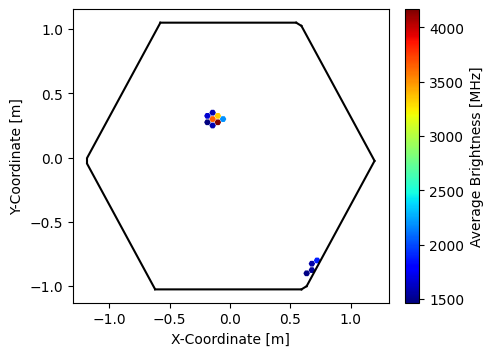

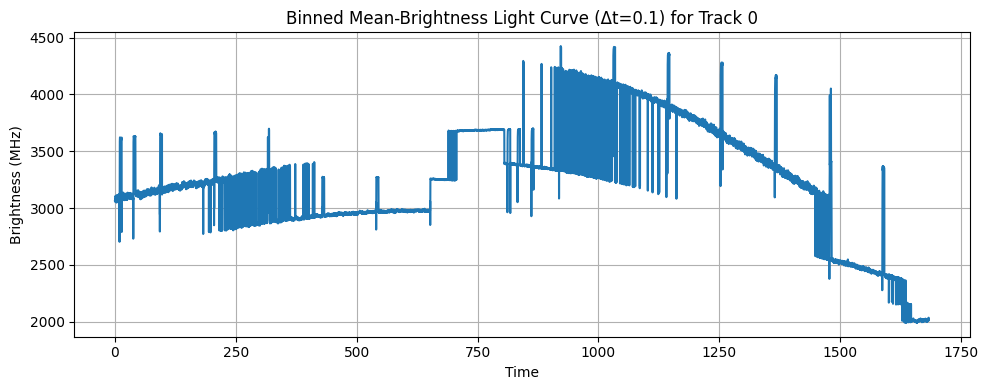

Track 0 overall mean brightness: 3228.162 MHz


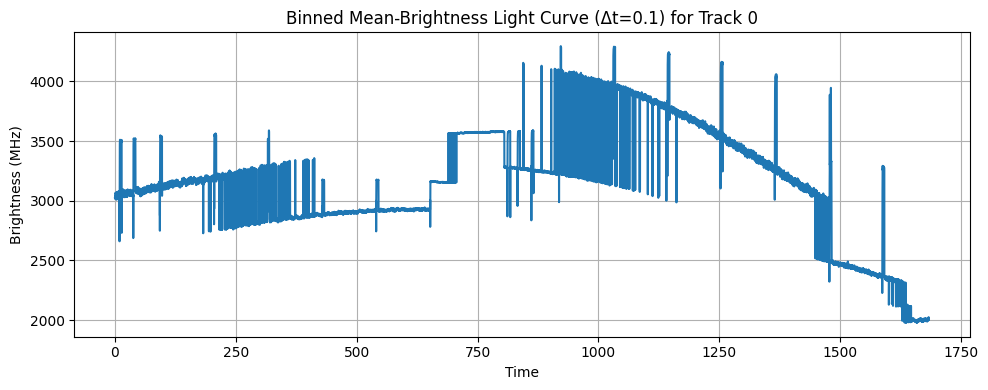

Track 0 overall mean brightness: 3150.556 MHz


In [3]:
import numpy as np
import pandas as pd
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter,
    plot_brightness_in_trackly,
    plot_brightness_in_track,
    plot_binned_mean_flux_light_curve
)
import matplotlib.pyplot as plt

# --- 1) build your flat-field model & coeff lookup ---
fmodel = FlatFieldModel()
date   = pd.to_datetime("2020-07-18")
tel_id = 5
coeffs = fmodel.get_FlatField(date, tel_id)
flat_hg = coeffs['Coefficient_hg']  # Series indexed by pixel
flat_lg = coeffs['Coefficient_lg']  # Series indexed by pixel

# --- 2) load & sort your tracks as before ---
typed_nn_pix = get_typed_nn_pix(5)
new_high_pixel = read_single_run_utc_cut(161097)
pix, tmp, brightness = new_high_pixel
tracks, possible_meteorites = track_sorter(pix, tmp, brightness, typed_nn_pix)

# --- 3) post-correct each track’s brightness ---
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    # lookup C for each pixel in the track
    C = np.array([flat_lg.loc[p] for p in pix_list], dtype=float)
    # divide the raw brightness by C
    bright_flat = np.array(bright_list, dtype=float) / C
    tracks_flat.append((pix_list, time_list, bright_flat))

# --- 4) inspect & plot using the flat-fielded tracks ---
for i, track in enumerate(tracks):
    pix = track[0]
    times = track[1]
    brightness = track[2]
    print(f"Track {i} — Unique Pixels: {len(set(pix))}")
    print(f"  First  → Pixel ID: {pix[0]}, Time: {times[0]}, Brightness: {brightness[0]}")
    print(f"  Last   → Pixel ID: {pix[-1]}, Time: {times[-1]}, Brightness: {brightness[-1]}")

for i, (pix_list, time_list, bright_flat) in enumerate(tracks_flat):
    print(f"Track {i} — Unique Pixels: {len(set(pix_list))}")
    print(f"  First  → Pixel ID: {pix_list[0]}, Time: {time_list[0]}, Brightness_flat: {bright_flat[0]}")
    print(f"  Last   → Pixel ID: {pix_list[-1]}, Time: {time_list[-1]}, Brightness_flat: {bright_flat[-1]}")

plot_brightness_in_trackly(tracks_flat)
plot_brightness_in_track(tracks_flat)
plot_binned_mean_flux_light_curve(tracks_flat, track_number=0, time_bin_size=0.1)
plot_binned_mean_flux_light_curve(tracks, track_number=0, time_bin_size=0.1)
plt.show()


In [73]:
# list of brightness value difference between tracks_flat and tracks
brightness_diff = []
for i, (pix_list, time_list, bright_flat) in enumerate(tracks_flat):
    original_brightness = tracks[i][2]
    diff = np.array(bright_flat) - np.array(original_brightness)
    brightness_diff.append(diff)
# Print the differences for inspection
for i, diff in enumerate(brightness_diff):
    print(f"Track {i} Brightness Difference: {diff[:5]} ... (total {len(diff)} values)")
    
# Show the initial brightness values and the corrected values for the first track
print("Original Brightness (Track 0):", tracks[0][2][:5])
print("Corrected Brightness (Track 0):", tracks_flat[0][2][:5])
print("Brightness Difference (Track 0):", brightness_diff[0][:5])

# average brightness difference for track 0
avg_diff_track_0 = np.mean(brightness_diff[0])
print(f"Average Brightness Difference for Track 0: {avg_diff_track_0:.6f} MHz")

Track 0 Brightness Difference: [-100.06012188    6.77218015  108.73423872 -100.38790074    6.77685218] ... (total 32395 values)
Track 1 Brightness Difference: [-101.16017953 -101.03681029 -101.01278576 -100.93097247 -100.98032017] ... (total 1003 values)
Track 2 Brightness Difference: [-36.11484214 -36.11339872 -36.09824281 -36.10690333 -36.12951691] ... (total 1163 values)
Original Brightness (Track 0): [4136.37, 1884.37, 3011.33, 4149.92, 1885.67]
Corrected Brightness (Track 0): [4036.30987812 1891.14218015 3120.06423872 4049.53209926 1892.44685218]
Brightness Difference (Track 0): [-100.06012188    6.77218015  108.73423872 -100.38790074    6.77685218]
Average Brightness Difference for Track 0: -6.950199 MHz


Reading high_pix_161098_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161098/high_pix_161098_CT_5_cut.h5
read pix:
read time:
read brightness:


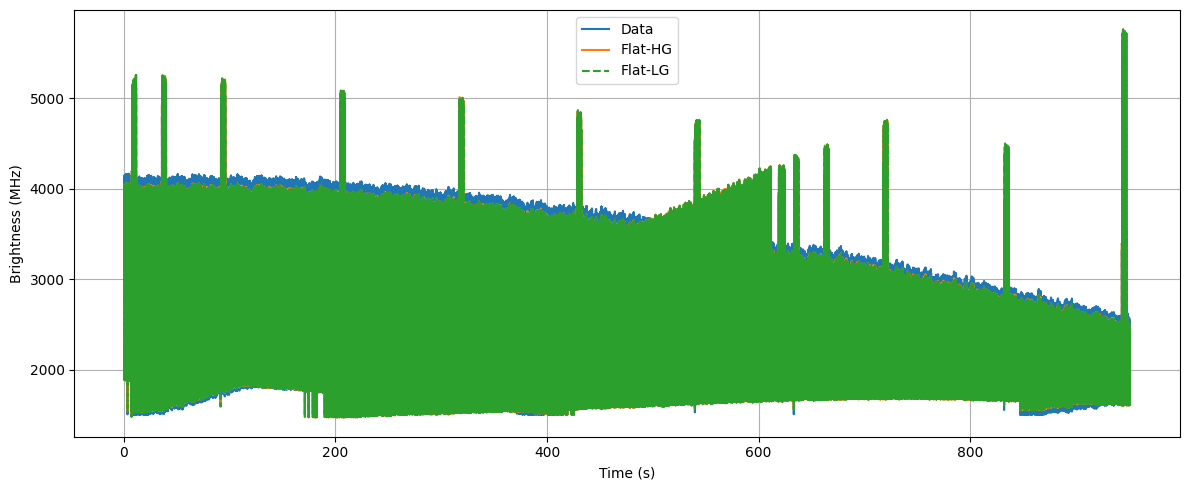

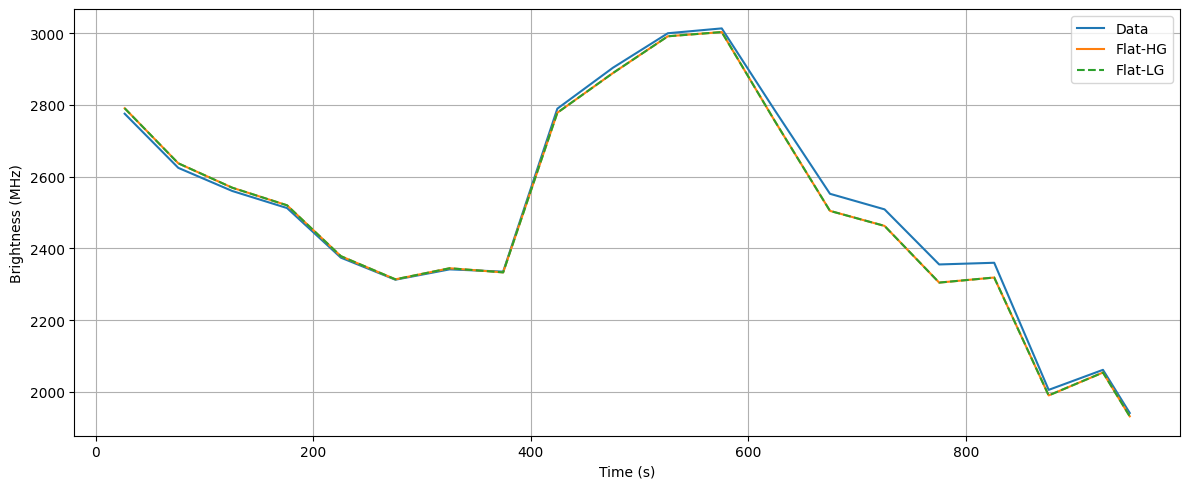

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter,
)

# --- 1) build your flat-field model & coeff lookup ---
fmodel = FlatFieldModel()
date   = pd.to_datetime("2020-07-18")
tel_id = 5
coeffs = fmodel.get_FlatField(date, tel_id)
flat_hg = coeffs['Coefficient_hg']  # Series indexed by pixel
flat_lg = coeffs['Coefficient_lg']  # Series indexed by pixel

# --- 2) load & sort your tracks as before ---
typed_nn_pix = get_typed_nn_pix(tel_id)
pix, tmp, brightness = read_single_run_utc_cut(161098)
tracks, possible_meteorites = track_sorter(pix, tmp, brightness, typed_nn_pix)

# --- 3) compute two sets of flat-fielded tracks ---
tracks_flat_hg = []
tracks_flat_lg = []
for pix_list, time_list, bright_list in tracks:
    br = np.array(bright_list, dtype=float)
    C_hg = np.array([flat_hg.loc[p] for p in pix_list], dtype=float)
    C_lg = np.array([flat_lg.loc[p] for p in pix_list], dtype=float)
    tracks_flat_hg.append((pix_list, time_list, br / C_hg))
    tracks_flat_lg.append((pix_list, time_list, br / C_lg))

# --- 4) define a helper to overplot one track ---
def plot_track_comparison(track_index, time_bin=None):
    """
    Plot raw vs HG-flat vs LG-flat for a single track.
    
    If time_bin is given (e.g. 0.1), it will bin the data in windows of that size
    and plot the binned-mean instead of individual points.
    """
    # unpack
    _, times, raw     = tracks[track_index]
    _, _,    flat_hg  = tracks_flat_hg[track_index]
    _, _,    flat_lg  = tracks_flat_lg[track_index]
    
    # optionally bin:
    if time_bin is not None:
        def binned_mean(x, y, dt):
            bins = np.arange(x.min(), x.max() + dt, dt)
            inds = np.digitize(x, bins)
            xm, ym = [], []
            for b in np.unique(inds):
                mask = inds == b
                xm.append(x[mask].mean())
                ym.append(y[mask].mean())
            return np.array(xm), np.array(ym)
        times_raw,   raw   = binned_mean(np.array(times), np.array(raw),   time_bin)
        times_hg,    flat_hg  = binned_mean(np.array(times), flat_hg,  time_bin)
        times_lg,    flat_lg  = binned_mean(np.array(times), flat_lg,  time_bin)
        times = times_raw  # all three share the same bin centers

    # plot
    plt.figure(figsize=(12,5))
    plt.plot(times, raw,     linestyle='-', label='Data')
    plt.plot(times, flat_hg, linestyle='-', label='Flat-HG')
    plt.plot(times, flat_lg, linestyle='--', label='Flat-LG')
    plt.xlabel('Time (s)')
    plt.ylabel('Brightness (MHz)')
    # plt.title(f'Track {track_index} light-curve comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 5) example usage: ---
# Plot track 0 unbinned
plot_track_comparison(0)

# Or plot track 0 with 0.1-unit time bins:
plot_track_comparison(0, time_bin=50)
